<a href="https://colab.research.google.com/github/AmedeeRoy/BirdGAN/blob/main/code/basicGAN/basicGAN_cnn_global.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN

In [1]:
# mount google drive
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [2]:
%cd drive/My\ Drive/

/content/drive/My Drive


## load data

In [3]:
# import python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import datetime as dt
from scipy.interpolate import  splrep, splev
import scipy.stats as st

import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader, Dataset
import torchvision as tv

In [4]:
def dist_ortho(lon1, lat1, lon2, lat2):
    R = 6377726
    pi = np.pi
    a = np.sin((lat1 - lat2)/2*pi/180)**2
    b = np.cos(lat1*pi/180)*np.cos(lat2*pi/180)
    c = np.sin((lon1- lon2)/2* pi/180)**2

    dist = R * 2* np.arcsin( np.sqrt(a + b*c))
    return dist

def cap(lon1, lat1, lon2, lat2):
    pi = np.pi

    # to radians
    lat1 = lat1*pi/180
    lat2 = lat2*pi/180
    lon1 = lon1*pi/180
    lon2 = lon2*pi/180

    delta_lon = lon2-lon1

    a = np.cos(lat1) * np.sin(lat2) - np.sin(lat1)*np.cos(lat2)*np.cos(delta_lon)
    b = np.sin(delta_lon) * np.cos(lat2)

    cap = np.arctan2(b , a)
    cap = cap%(2*pi)

    return cap*180/pi

def get_foraging_duration(data):
    var = []
    for tt in data.trip.unique():
      traj = data[data.trip == tt].copy()
      var.append(np.nansum(traj.dist_colony > 500))
      
    return np.array(var)

def get_daily_dist(data):
    var = []
    for tt in data.trip.unique():
      traj = data[data.trip == tt].copy()
      var.append( np.nansum(traj.step_distance) )
      
    return np.array(var)

def get_time_density(data):
    var = 0
    for tt in data.trip.unique():
      traj = data[data.trip == tt].copy()
      var += (traj.dist_colony.values > 500) 
    return np.array(var)

def get_direction_global(data):
    var = []
    for tt in data.trip.unique():
      traj = data[data.trip == tt].copy()
      dx = traj.lon.values[np.argmax(traj.dist_colony)] - colony[0]
      dy = traj.lat.values[np.argmax(traj.dist_colony)] - colony[1]
      var.append(np.arctan2(dy,dx)*360/(2*np.pi))
    return np.array(var)


def format_data(data):
  data['lon_std'] = (data['lon']- colony[0])* 2
  data['lat_std'] = (data['lat']- colony[1])* 2
  data['dist_colony'] = dist_ortho(colony[0], colony[1], data.lon, data.lat)
  # data['day'] = [t[-5:] for t in data.trip]

  data_new = pd.DataFrame()
  for t in data.trip.unique():
    traj = data[data.trip == t].copy()
    n = len(traj)

    step = dist_ortho( traj.lon.values[0:(n-1)], traj.lat.values[0:(n-1)], traj.lon.values[1:n], traj.lat.values[1:n])
    c = cap( traj.lon.values[0:(n-1)], traj.lat.values[0:(n-1)], traj.lon.values[1:n], traj.lat.values[1:n])
    direction = [d%360 - 360 if d%360 > 180 else d%360 for d in np.diff(c)]

    traj['step_distance'] = np.append(np.nan, step)
    traj['step_direction'] = np.append([np.nan, np.nan], direction)
    data_new = data_new.append(traj, ignore_index=True)

  return data_new

In [5]:
data_train = pd.read_table('./data/trips_SV_train.csv', sep = ',')
data_train['datetime'] = pd.to_datetime(data_train['datetime'], format='%Y-%m-%d %H:%M:%S')

data_test = pd.read_table('./data/trips_SV_test.csv', sep = ',')
data_test['datetime'] = pd.to_datetime(data_test['datetime'], format='%Y-%m-%d %H:%M:%S')

data = pd.concat([data_train, data_test])
data = data.iloc[::4, :]

In [6]:
colony = (-77.264, -11.773)
data = format_data(data)

In [7]:
data

,trip,datetime,lon,lat,step_speed,step_direction,dive,prediction,lon_std,lat_std,dist_colony,step_distance
0,P1108_11_SV_T1,2008-11-28 15:05:20,-77.264927,-11.773795,10.972217,NaN,NaN,0.103489,-0.001854,-0.001590,134.295329,NaN
1,P1108_11_SV_T1,2008-11-28 15:06:20,-77.268225,-11.777974,10.021646,NaN,NaN,0.000537,-0.008450,-0.009948,720.078571,587.828354
2,P1108_11_SV_T1,2008-11-28 15:07:20,-77.275128,-11.780898,13.179136,28.912925,NaN,0.000108,-0.022256,-0.015796,1497.770057,819.604238
3,P1108_11_SV_T1,2008-11-28 15:08:20,-77.281774,-11.783169,12.737054,4.155745,NaN,0.000047,-0.035548,-0.020338,2243.325254,767.047659
4,P1108_11_SV_T1,2008-11-28 15:09:20,-77.288302,-11.786137,13.140033,-5.670097,NaN,0.000030,-0.048604,-0.026274,3025.063861,784.307907
...,...,...,...,...,...,...,...,...,...,...,...,...
24104,P1112_39_SV_T1,2012-11-28 22:01:22,-77.286987,-11.793420,14.722527,-4.967451,NaN,0.000098,-0.045974,-0.040840,3382.399195,815.747197
24105,P1112_39_SV_T1,2012-11-28 22:02:22,-77.280502,-11.788518,13.911692,-14.491950,NaN,0.000047,-0.033004,-0.031036,2493.428276,892.783006
24106,P1112_39_SV_T1,2012-11-28 22:03:22,-77.275330,-11.782243,17.989255,-13.426851,NaN,0.000020,-0.022660,-0.018486,1607.119327,897.492853
24107,P1112_39_SV_T1,2012-11-28 22:04:22,-77.268471,-11.775536,17.448301,6.134219,NaN,0.000055,-0.008942,-0.005072,563.077290,1056.407666


In [8]:
padding = 200

traj_lon = np.zeros((len(data.trip.unique()), padding))
traj_lat = np.zeros((len(data.trip.unique()), padding))

i = 0
for tt in data.trip.unique():
    traj = data[data.trip == tt].copy()
    coord = traj.loc[:,('lon_std', 'lat_std')].to_numpy()
    coord = coord[np.arange(0, coord.shape[0]),:]

    idx = np.random.randint(padding - coord.shape[0] - 1)
    traj_lon[i, idx:idx+coord.shape[0]] = coord[:,0]
    traj_lat[i, idx:idx+coord.shape[0]] = coord[:,1]
    i += 1

In [9]:
class TrajDataSet(Dataset):
    def __init__(self,  lon, lat, transform=None):
        self.lon = lon
        self.lat = lat 
        self.transform = transform

    def __len__(self):
        return self.lon.shape[0]

    def __getitem__(self, idx):
        
        # select coordinates
        sample = np.stack([self.lon[idx,:], self.lat[idx,:]])

        if self.transform:
            sample = self.transform(sample)

        return sample

class ToTensor(object):
    """Convert ndarrays in sample to Tensors."""

    def __call__(self, sample):
        return torch.FloatTensor(sample)

In [10]:
# hyperparameters
batch_size = 40
resolution = 60

## reduce size dataset
train_set = TrajDataSet(traj_lon, traj_lat, transform= ToTensor())
train_loader = DataLoader(train_set, batch_size=batch_size, num_workers = 0, shuffle = True, drop_last=True)

In [11]:
x =  next(iter(train_loader))

In [16]:
dicolour = { 'blue':   '#1f77b4',  # muted blue
             'orange': '#ff7f0e',  # safety orange
             'green':  '#2ca02c',  # cooked asparagus green
             'red':    '#d62728',  # brick red
             'purple': '#9467bd',  # muted purple
             'brown':  '#8c564b',  # chestnut brown
             'pink':   '#e377c2',  # raspberry     yogurt pink
             'gray':   '#7f7f7f',  # middle gray
            'yellow': '#bcbd22'   # curry yellow-green
           }

def format_simulation(x):
    x = x.detach().numpy()

    data_fake = pd.DataFrame()

    for i in range(x.shape[0]):
      trip = 'simulation_'+ str(i).rjust( 2, '0')
      n = x.shape[2]

      lon_std = x[i,0,:]
      lat_std = x[i,1,:]
      lon = lon_std/2 + colony[0]
      lat = lat_std/2 + colony[1]

      rows = pd.DataFrame( {'trip':trip, 'lon':lon.tolist(), 'lat':lat.tolist()})
      
      data_fake = data_fake.append(rows, ignore_index=True)

    data_fake = format_data(data_fake)
    return data_fake

def kde1d(z, bw=2):
  kernel = st.gaussian_kde(z)
  kernel.set_bandwidth(bw_method=bw)
  x = np.arange(min(z), max(z), 1)
  return kernel

def smooth(y, s=1):
  ## b-spline smoothing
  x = np.arange(len(y))
  bspl = splrep(x, y, s=s)
  bspl_y = splev(x,bspl)
  bspl_y[bspl_y <0] =0
  return bspl_y
  

def kde2d(data, bw=0.5):
  # KDE computation
  select = (data.dist_colony > 500) & (data.step_distance < 500)
  xx, yy = np.mgrid[-2:2:0.05, -2:2:0.05]
  positions = np.vstack([xx.ravel(), yy.ravel()])
  values = np.vstack([data.lon_std[select], data.lat_std[select]])
  kernel = st.gaussian_kde(values)
  kernel.set_bandwidth(bw_method=bw)
  foraging_area = np.reshape(kernel(positions).T, xx.shape)

  return xx, yy, foraging_area

def get_score(data, data_fake):

  plt.figure(figsize = (10,10))

  plt.subplot(2,2,1)
  ## DAILY DISTANCE
  y = get_daily_dist(data)
  y_false = get_daily_dist(data_fake)

  dy = kde1d(y/1e3, bw = 0.5)
  dy_false = kde1d(y_false/1e3, bw = 0.5)

  bins = np.arange(0, 100, 10)
  # plt.hist(y/1e3, alpha = 0.5, edgecolor='k', bins = bins, density = True, color = dicolour['blue'], label = 'True')
  # plt.hist(y_false/1e3, alpha = 0.5, edgecolor='k', bins = bins, density = True, color = dicolour['orange'], label = 'Simulation')
  x = np.arange(0,100, 1)
  plt.plot(x, dy(x), color = dicolour['blue'], label = 'True')
  plt.plot(x, dy_false(x), color = dicolour['orange'], label = 'Simulation')
  plt.legend()
  plt.title('Daily Distance (km)')

  score_daily_dist = np.sum((dy_false(x) - dy(x))**2) / np.sum( dy(x)**2)

  plt.subplot(2,2,2)
  ## FORAGING DURATION
  y = get_foraging_duration(data)
  y_false = get_foraging_duration(data_fake)

  dy = kde1d(y, bw = 0.5)
  dy_false = kde1d(y_false, bw = 0.5)

  bins = np.arange(0, 300, 15)
  # plt.hist(y, alpha = 0.5, edgecolor='k', bins = bins, density = True, color = dicolour['blue'], label = 'True')
  # plt.hist(y_false, alpha = 0.5, edgecolor='k', bins = bins, density = True, color = dicolour['orange'], label = 'Simulation')

  x = np.arange(0,300, 1)
  plt.plot(x, dy(x), color = dicolour['blue'], label = 'True')
  plt.plot(x, dy_false(x), color = dicolour['orange'], label = 'Simulation')
  plt.legend()
  plt.title('Foraging Duration (min)')

  score_foraging_duration = np.sum((dy_false(x) - dy(x))**2) / np.sum( dy(x)**2)

  plt.subplot(2,2,3)
  # FORAGING AREA
  xx,yy,f = kde2d(data, bw=0.5)
  xx,yy,f_false = kde2d(data_fake, bw=0.5)

  plt.contour(xx,yy,f, cmap = 'Blues', vmin = -1, vmax = 1, alpha = 0.8, levels = [0.01, 0.1, 0.5, 1])
  plt.contour(xx,yy,f_false, cmap = 'Oranges', vmin = -1, vmax = 1, alpha = 0.8, levels = [0.01, 0.1, 0.5, 1])
  plt.title('Foraging Areas')

  score_foraging_area = np.sum((f_false - f)**2) / np.sum( f**2)

  # plt.subplot(2,2,4)
  # # FORAGING TIMES
  # y = get_time_density(data)
  # dy  = smooth(y, s = 2000)

  # y_false = get_time_density(data_fake)
  # dy_false  = smooth(y_false, s = 200)

  # plt.plot(data.datetime[:900], dy/np.sum(dy))
  # plt.plot(data.datetime[:900], dy_false/np.sum(dy_false))
  # plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H-%M'))
  # plt.title('Foraging Time')

  # score_foraging_times = np.sum((dy_false/np.sum(dy_false) - dy/np.sum(dy))**2) / np.sum( (dy/np.sum(dy))**2)

  return  [score_daily_dist, score_foraging_duration, score_foraging_area]

In [17]:
data_fake = format_simulation(x)
data_fake

,trip,lon,lat,lon_std,lat_std,dist_colony,step_distance,step_direction
0,simulation_00,-77.264,-11.773,1.220703e-07,4.730225e-07,0.027154,NaN,NaN
1,simulation_00,-77.264,-11.773,1.220703e-07,4.730225e-07,0.027154,0.0,NaN
2,simulation_00,-77.264,-11.773,1.220703e-07,4.730225e-07,0.027154,0.0,0.0
3,simulation_00,-77.264,-11.773,1.220703e-07,4.730225e-07,0.027154,0.0,0.0
4,simulation_00,-77.264,-11.773,1.220703e-07,4.730225e-07,0.027154,0.0,0.0
...,...,...,...,...,...,...,...,...
7995,simulation_39,-77.264,-11.773,1.220703e-07,4.730225e-07,0.027154,0.0,0.0
7996,simulation_39,-77.264,-11.773,1.220703e-07,4.730225e-07,0.027154,0.0,0.0
7997,simulation_39,-77.264,-11.773,1.220703e-07,4.730225e-07,0.027154,0.0,0.0
7998,simulation_39,-77.264,-11.773,1.220703e-07,4.730225e-07,0.027154,0.0,0.0


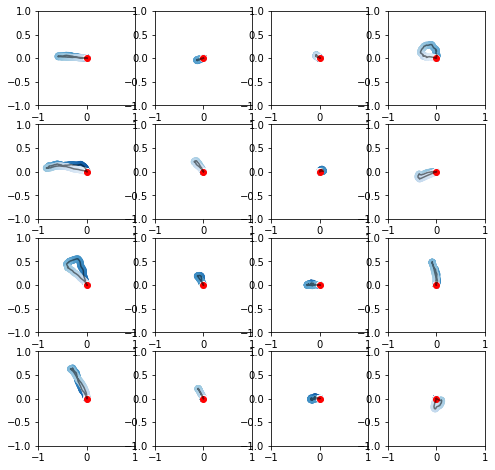

In [18]:
plt.figure(figsize = (8,8))
i = 4

for i in range(16):
  plt.subplot(4,4,i+1)
  plt.plot(x.numpy()[i,0,:], x.numpy()[i,1,:], c = 'black', alpha = 0.5)
  plt.scatter(x.numpy()[i,0,:], x.numpy()[i,1,:], c=np.arange(padding), cmap='Blues_r')
  plt.scatter(0,0, c = 'red')
  plt.xlim(-1,1)
  plt.ylim(-1,1)


[0.04928111043349765, 0.030359152979309034, 0.06814588234572319]

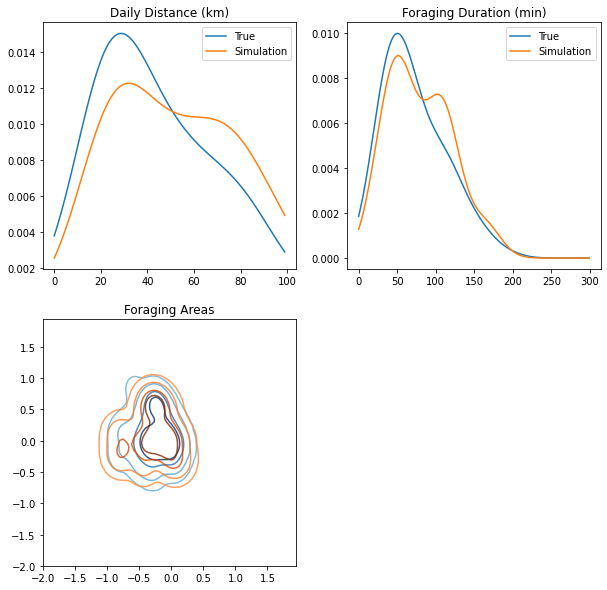

In [19]:
get_score(data, data_fake)

## deep networks

Architecture guidelines for stable Deep Convolutional GANs (Radford et al. 2016)

- Replace any pooling layers with strided convolutions (discriminator) and fractional-strided
convolutions (generator).
- Use batchnorm in both the generator and the discriminator.
- Remove fully connected hidden layers for deeper architectures.
- Use ReLU activation in generator for all layers except for the output, which uses Tanh.
- Use LeakyReLU activation in the discriminator for all layers.



In [20]:
import torch
from torch import nn
from torch import optim
import torchvision as tv
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [23]:
class CNNGenerator(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(    
            nn.ConvTranspose1d(512, 128, kernel_size = 25, stride = 2, padding = 0, bias = False),
            nn.BatchNorm1d(128),
            nn.ReLU(True),

            nn.ConvTranspose1d(128, 32, kernel_size = 4, stride = 2, padding = 1, bias = False),
            nn.BatchNorm1d(32),
            nn.ReLU(True),

            nn.ConvTranspose1d(32, 8, kernel_size = 4, stride = 2, padding = 1, bias = False),
            nn.BatchNorm1d(8),
            nn.ReLU(True),

            nn.ConvTranspose1d(8, 2, kernel_size = 4, stride = 2, padding = 1, bias = False),
            nn.Tanh()
         )

    def forward(self, z):    
      out = self.cnn(z)
      return out

In [24]:
z = torch.rand((batch_size, 512, 1))
gen = CNNGenerator()
gen(z).shape

torch.Size([40, 2, 200])

In [25]:
class CNNDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
             
        self.cnn = nn.Sequential(
            nn.Conv1d(2, 8, kernel_size = 4, stride = 2, padding = 1, bias = False),
            nn.BatchNorm1d(8),
            nn.LeakyReLU(0.2, inplace=False),

            nn.Conv1d(8, 32, kernel_size = 4, stride = 2, padding = 1, bias = False),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2, inplace=False),

            nn.Conv1d(32, 128, kernel_size = 4, stride = 2, padding = 1, bias = False),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2, inplace=False),

            nn.Conv1d(128, 1, kernel_size=25, stride=2, padding=0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):

        out = self.cnn(x)
        return out.squeeze(1)


In [26]:
dis = CNNDiscriminator()

In [27]:
dis(x).shape

torch.Size([40, 1])

# training

In [28]:
def weights_init(m):
    """
    This function initializes the model weights randomly from a 
    Normal distribution. This follows the specification from the DCGAN paper.
    https://arxiv.org/pdf/1511.06434.pdf
    Source: https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html
    """
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = CNNGenerator().to(device)
discriminator = CNNDiscriminator().to(device)


### WEIGHT INITIALIZATION
generator.apply(weights_init)
discriminator.apply(weights_init)

criterion = nn.BCELoss()

lr = 0.0002
optim_d = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
optim_g = optim.Adam(generator.parameters(),lr= lr, betas=(0.5, 0.999))

target_ones = torch.ones((batch_size, 1), device=device)
target_zeros = torch.zeros((batch_size, 1), device=device)

Epoch [1/1000] -----------------------------------------------------------------------------
G: 1.08, Dr : 0.65, Df : 0.72
Generator score : 20.0 %, Discriminator true positive : 80.0 %, Discriminator true negative : 77.5 %


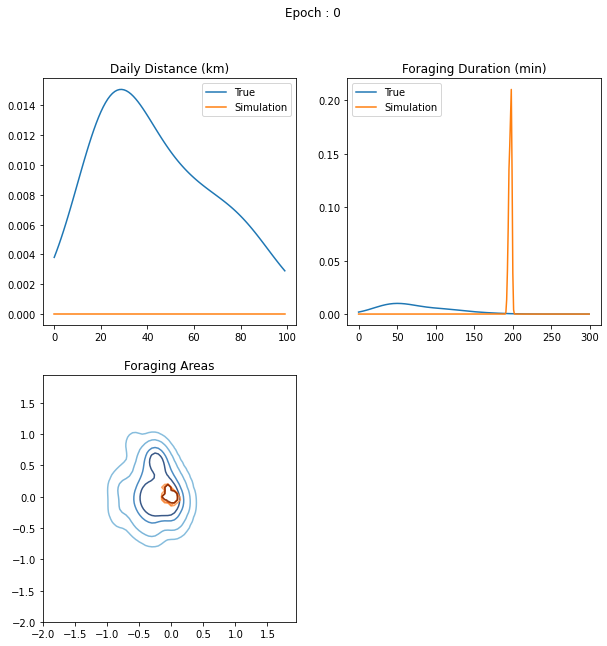

Epoch [101/1000] -----------------------------------------------------------------------------
G: 2.47, Dr : 0.52, Df : 0.48
Generator score : 0.0 %, Discriminator true positive : 95.0 %, Discriminator true negative : 37.5 %


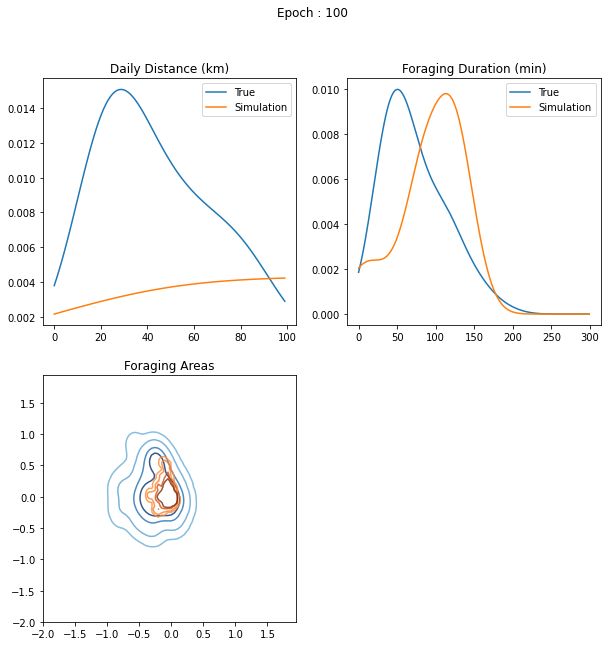

Epoch [201/1000] -----------------------------------------------------------------------------
G: 1.86, Dr : 0.39, Df : 0.35
Generator score : 25.0 %, Discriminator true positive : 92.5 %, Discriminator true negative : 100.0 %


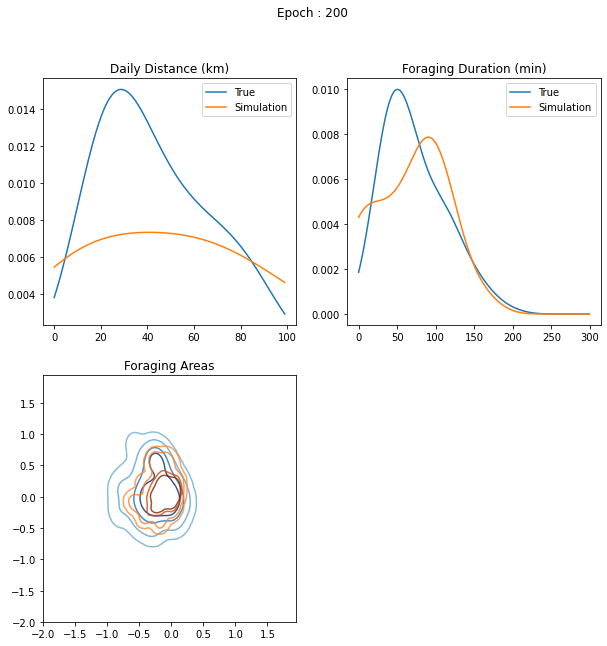

Epoch [301/1000] -----------------------------------------------------------------------------
G: 2.43, Dr : 0.32, Df : 0.3
Generator score : 0.0 %, Discriminator true positive : 100.0 %, Discriminator true negative : 90.0 %


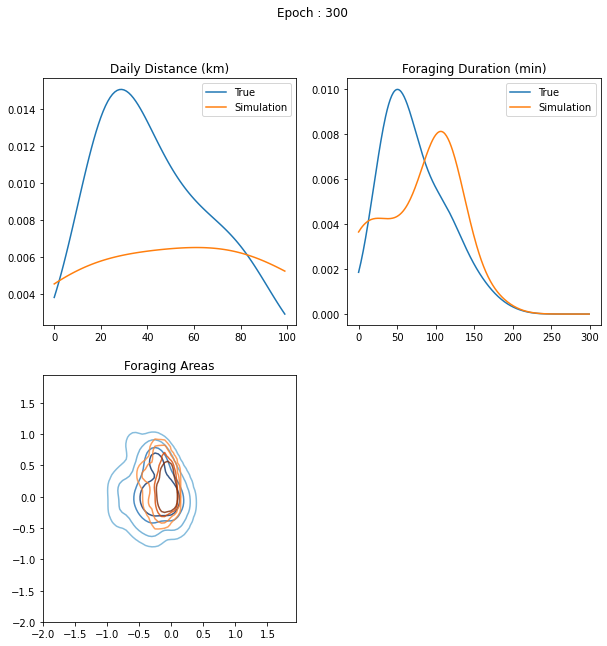

Epoch [401/1000] -----------------------------------------------------------------------------
G: 2.79, Dr : 0.26, Df : 0.29
Generator score : 0.0 %, Discriminator true positive : 100.0 %, Discriminator true negative : 95.0 %


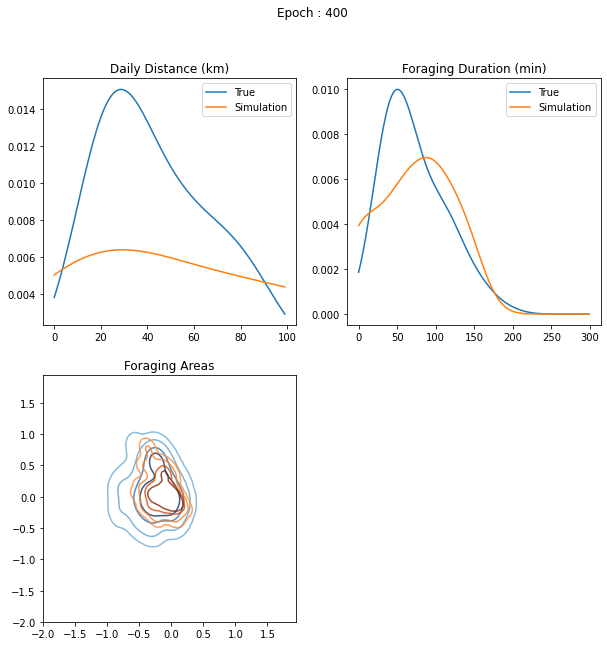

Epoch [501/1000] -----------------------------------------------------------------------------
G: 2.62, Dr : 0.17, Df : 0.18
Generator score : 2.5 %, Discriminator true positive : 100.0 %, Discriminator true negative : 100.0 %


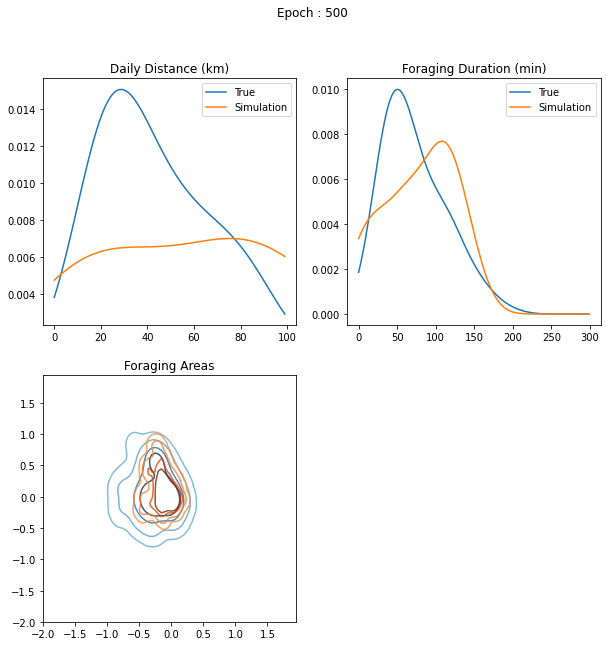

Epoch [601/1000] -----------------------------------------------------------------------------
G: 3.33, Dr : 0.2, Df : 0.15
Generator score : 0.0 %, Discriminator true positive : 92.5 %, Discriminator true negative : 100.0 %


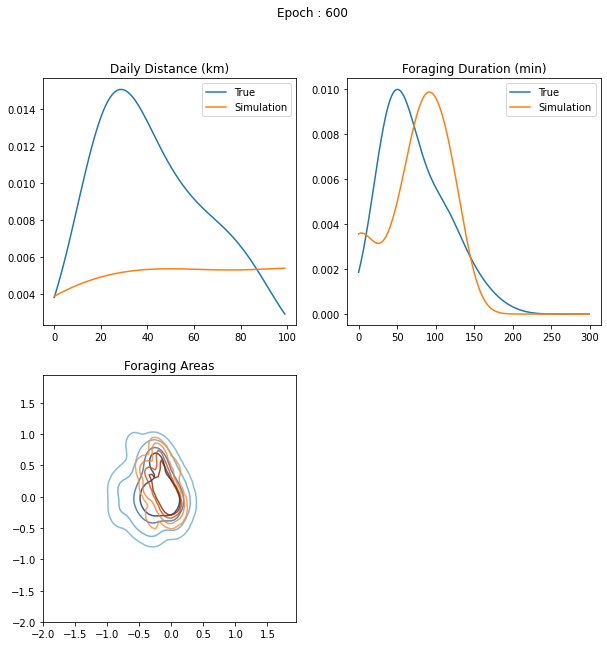

Epoch [701/1000] -----------------------------------------------------------------------------
G: 3.0, Dr : 0.17, Df : 0.12
Generator score : 0.0 %, Discriminator true positive : 100.0 %, Discriminator true negative : 97.5 %


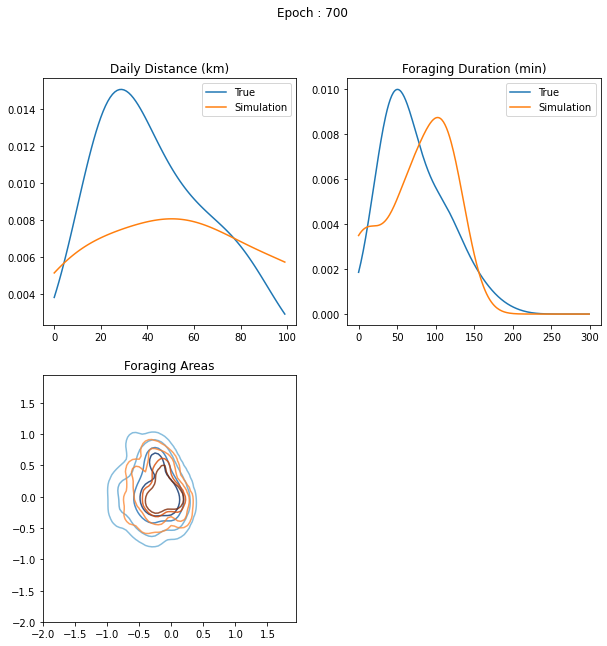

Epoch [801/1000] -----------------------------------------------------------------------------
G: 3.33, Dr : 0.18, Df : 0.14
Generator score : 0.0 %, Discriminator true positive : 90.0 %, Discriminator true negative : 97.5 %


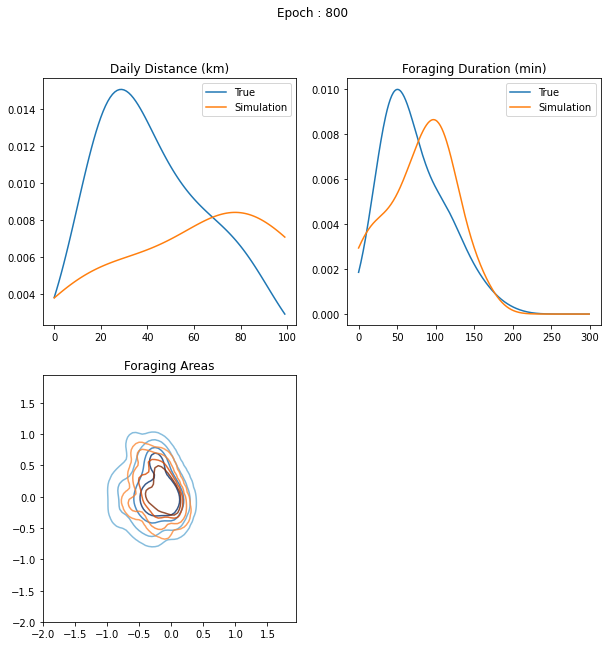

Epoch [901/1000] -----------------------------------------------------------------------------
G: 3.73, Dr : 0.34, Df : 0.22
Generator score : 2.5 %, Discriminator true positive : 30.0 %, Discriminator true negative : 100.0 %


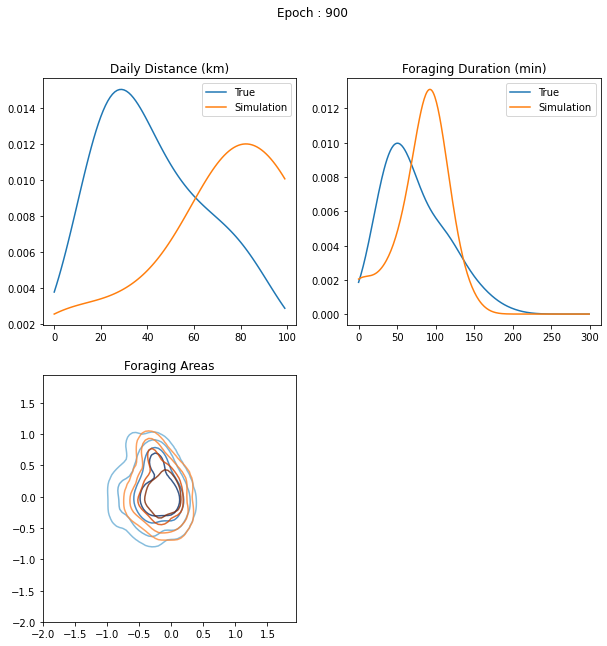

In [30]:
# Train the model
nb_epoch = 1000
score = []

for epoch in range(nb_epoch):
    i = 0

    # if epoch%100 == 0:
    #     lr /= 10
    #     optim_d = optim.Adam(discriminator.parameters(), lr=lr)
    #     optim_g = optim.Adam(generator.parameters(),lr=lr)

    loss_g_running, loss_d_real_running, loss_d_fake_running = 0, 0, 0
    for batch, x in enumerate(train_loader):
        
        i+= 1
        #### TRAIN DISCRIMINATOR
        ## true samples
        x = x.to(device)

        discriminator.zero_grad()
        pred_real = discriminator(x)
        loss_real = criterion(pred_real, target_ones)

        ## false samples
        z = torch.randn((batch_size, 512, 1), device=device)
        with torch.no_grad():
            fake_samples = generator(z)
        pred_fake = discriminator(fake_samples)
        loss_fake = criterion(pred_fake, target_zeros)
        
        # combine
        loss = (loss_real + loss_fake) / 2
        loss.backward()
        optim_d.step()

        loss_d_real_running += loss_real.item()
        loss_d_fake_running += loss_fake.item()

        # score discriminator
        score_d_fake = np.mean(pred_fake.detach().numpy()<0.5)
        score_d_real = np.mean(pred_real.detach().numpy()>0.5)

        #### TRAIN GENERATOR
        generator.zero_grad()
        z = torch.randn((batch_size, 512, 1), device=device)

        generated = generator(z)
        classifications = discriminator(generated)
        loss = criterion(classifications, target_ones)
        loss.backward()
        optim_g.step()

        loss_g_running += loss.item()

        # score generator
        score_g = np.mean(classifications.detach().numpy()>0.5)
    

    if epoch%100 == 0:
        print('Epoch [{}/{}] -----------------------------------------------------------------------------'
            .format(epoch+1, nb_epoch, i, len(train_loader)))
        print('G: {}, Dr : {}, Df : {}'
            .format(np.round(loss_g_running/batch, 2), np.round(loss_d_real_running/batch, 2), np.round(loss_d_fake_running/batch, 2)))
        print('Generator score : {} %, Discriminator true positive : {} %, Discriminator true negative : {} %'
            .format(np.round(score_g*100, 2), np.round(score_d_real*100, 2), np.round(score_d_fake*100, 2)))
        

        z = torch.randn((batch_size, 512, 1), device=device)
        with torch.no_grad():
          generated = generator(z)
        
        data_fake = format_simulation(generated)
        score.append(get_score(data, data_fake))
        plt.suptitle('Epoch : ' + str(epoch))
        # plt.savefig('score' + str(epoch).rjust( 4, '0') + '.png')
        plt.show()
        plt.close()

In [32]:
torch.save(generator, 'basicGAN_cnn_G.pt')
torch.save(discriminator, 'basicGAN_cnn_D.pt')

# generator = torch.load('basicGAN_cnn_G.pt')
# discriminator = torch.load('basicGAN_cnn_D.pt')

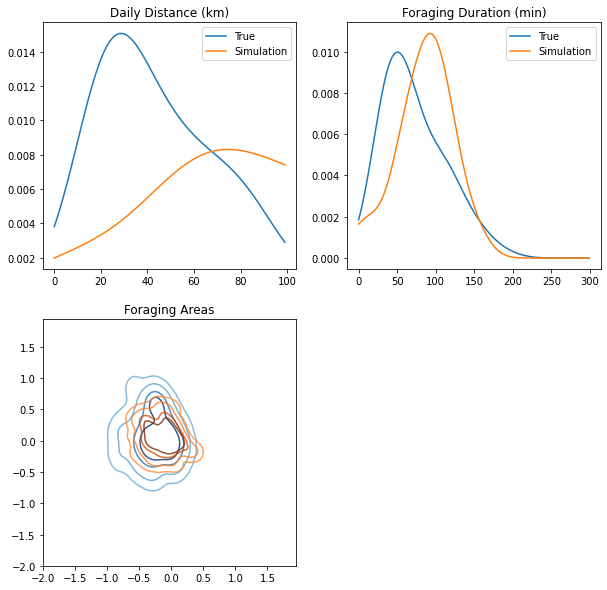

In [33]:
z = torch.randn((batch_size, 512, 1), device=device)
generated = generator(z)

data_fake = format_simulation(generated)
score.append(get_score(data, data_fake))
plt.show()
plt.close()

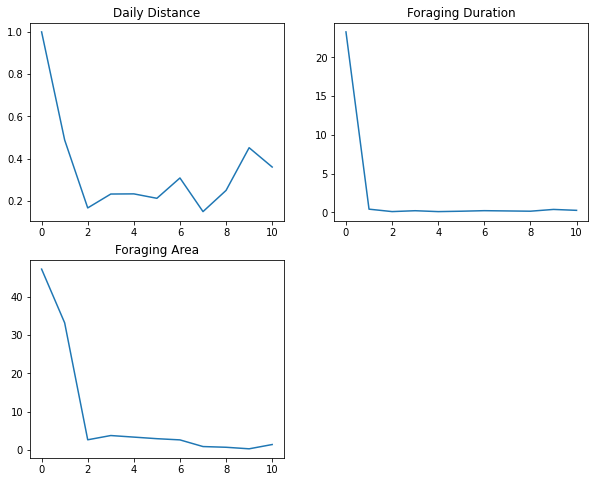

In [36]:
score = np.array(score)
# [score_daily_dist, score_foraging_duration, score_foraging_area, score_foraging_times]
name = ['Daily Distance', 'Foraging Duration', 'Foraging Area', 'Foraging Times']

plt.figure(figsize=(10,8))
for i in range(3):
  plt.subplot(2,2,i+1)
  plt.plot(score[:, i])
  plt.title(name[i])

## visualizing

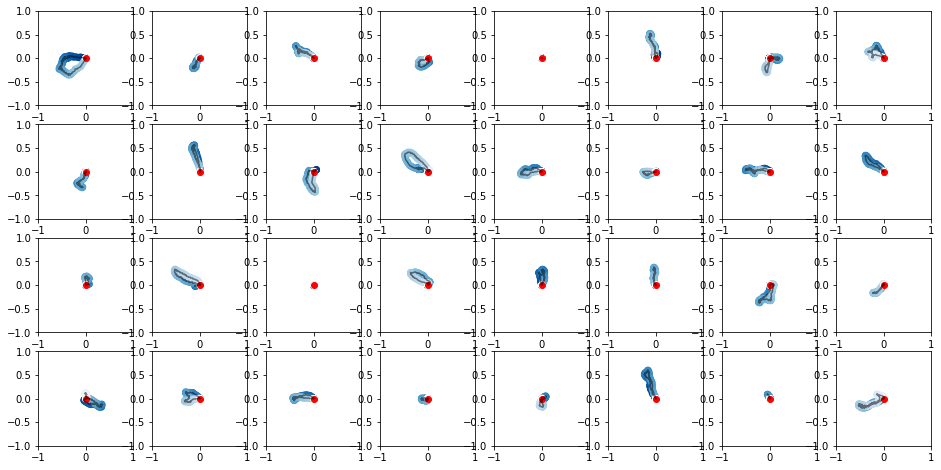

In [37]:
traj = generated.detach().numpy()

plt.figure(figsize = (16,8))

for i in range(32):
  plt.subplot(4,8,i+1)
  plt.plot(traj[i,0,:], traj[i,1,:], c = 'black', alpha = 0.5)
  plt.scatter(traj[i,0,:], traj[i,1,:], c=np.arange(padding), cmap='Blues_r')
  plt.scatter(0,0, c = 'red')
  plt.xlim(-1,1)
  plt.ylim(-1,1)